# Log or Simple \U0001F4D0
### Two definitions of "the return". Both correct. Not interchangeable.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

One adds up across time. The other adds up across assets. No definition does both, every
codebase mixes them somewhere, and the mistake is invisible on a bond fund and enormous on
bitcoin. This notebook measures the damage.

> \U0001F4D3 **This is the plain-language layer.** The expansion, the Jensen argument and the
> terminal-wealth accounting are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Are the two returns different? | By about **half the variance** per period — nothing on bills, a fortune on bitcoin. |
| Does it change a headline number? | Yes: the "average annual return" of a volatile asset can be strongly positive while its holders lost money. |
| Where is the actual bug? | Building a **portfolio** by weighting *log* returns. It always understates, never warns you, and compounds. |
| What is the rule? | Logs across time. Simple across assets. Say which one you are quoting. |

## 1 · The claim

> *"Just use log returns — they're additive, they're symmetric, and everyone in academia uses
> them."*

Half right. Log returns are additive **across time**. They are not additive across *assets*,
and a portfolio is an average across assets.

## 2 · So what?

Because the difference is second-order in the return, it hides in exactly the places where
returns are large — leveraged funds, emerging markets, crypto — which are also the places
where people most want a headline number to quote.

In [2]:
from log_vs_simple import data, strategy as st

px = data.load_prices()
print(f"as-of {data.AS_OF}")
for tk in data.TICKERS:
    s = px[tk].dropna()
    v = s.pct_change().std() * np.sqrt(252)
    print(f"  {tk:8s} {s.index[0].date()} -> {s.index[-1].date()}  "
          f"n={len(s):6,}  annualised vol {v:6.1%}")

as-of 2026-06-30
  BIL      2007-05-30 -> 2026-06-30  n= 4,802  annualised vol   0.5%
  TLT      2002-07-30 -> 2026-06-30  n= 6,018  annualised vol  14.3%
  SPY      1993-01-29 -> 2026-06-30  n= 8,411  annualised vol  18.6%
  QQQ      1999-03-10 -> 2026-06-30  n= 6,869  annualised vol  27.0%
  EEM      2003-04-14 -> 2026-06-30  n= 5,840  annualised vol  27.1%
  GLD      2004-11-18 -> 2026-06-30  n= 5,436  annualised vol  18.2%
  TQQQ     2010-02-11 -> 2026-06-30  n= 4,120  annualised vol  61.2%
  BTC-USD  2014-09-17 -> 2026-06-30  n= 4,305  annualised vol  55.3%


## 3 · How would we even know?

There is nothing to estimate. `ln(1+R) ≤ R` always, with the gap growing like `R²/2`. The only
question is how big that gap is on real tapes, so we measure it.

## 4 · The teardown

### 4.1 The gap, tape by tape

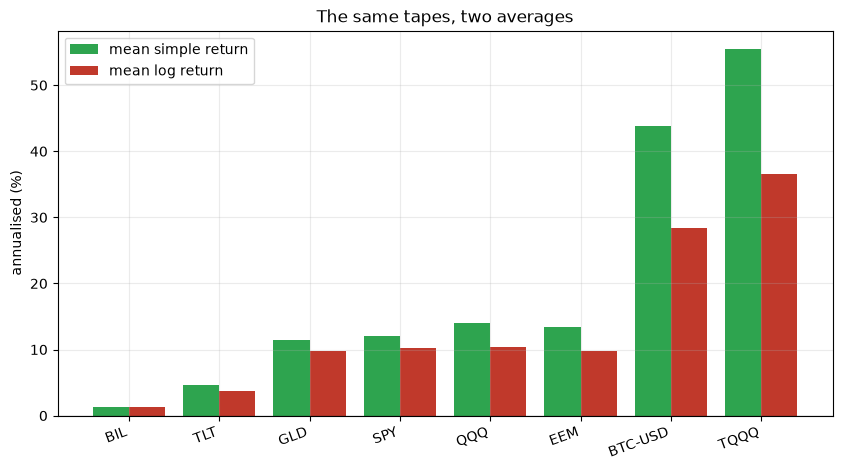

,vol_ann,mean_simple_ann,mean_log_ann,gap_ann,half_var_ann,cagr
ticker,,,,,,
BIL,0.0049,0.0136,0.0135,0.0000,0.0000,0.0136
TLT,0.1430,0.0469,0.0367,0.0102,0.0102,0.0374
GLD,0.1818,0.1147,0.0981,0.0166,0.0165,0.1031
SPY,0.1858,0.1201,0.1029,0.0173,0.0173,0.1083
QQQ,0.2695,0.1405,0.1042,0.0363,0.0363,0.1098
EEM,0.2712,0.1338,0.0972,0.0367,0.0368,0.1020
BTC-USD,0.5531,0.4383,0.2841,0.1542,0.1530,0.3286
TQQQ,0.6115,0.5548,0.3656,0.1892,0.1870,0.4414


In [3]:
dt = st.drag_table(px).sort_values("vol_ann")
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dt))
ax.bar(x - 0.2, dt["mean_simple_ann"] * 100, width=0.4, color="#2ea44f", label="mean simple return")
ax.bar(x + 0.2, dt["mean_log_ann"] * 100, width=0.4, color="#c0392b", label="mean log return")
ax.set_xticks(x); ax.set_xticklabels(dt.index, rotation=20, ha="right")
ax.set_ylabel("annualised (%)"); ax.axhline(0, color="k", lw=0.8)
ax.set_title("The same tapes, two averages")
ax.legend()
plt.show()
dt[["vol_ann", "mean_simple_ann", "mean_log_ann", "gap_ann", "half_var_ann", "cagr"]].round(4)

> \U0001F52C **For the quants.** The `half_var_ann` column is the σ²/2 prediction. It tracks
> the gap closely at low volatility and starts to under-explain it once skewness and kurtosis
> matter, which is the third and fourth term of the expansion showing up.

### 4.2 Why "average annual return" is a trick question

In [4]:
wild = dt["gap_ann"].idxmax()
R = px[wild].dropna().pct_change().dropna()
t = st.annualisation_table(R)
print(f"{wild}: four ways to state one 'average annual return'\n")
print(t.round(4).to_string())
print(f"\nAnd the number an actual holder experienced (CAGR): "
      f"{dt.loc[wild, 'cagr']:+.2%}/yr")

TQQQ: four ways to state one 'average annual return'

                             value                                                       claims
method                                                                                         
arithmetic x 252            0.5548       the expected return of one year, if you never compound
(1 + mean)^252 - 1          0.7406  the return of a hypothetical path with no volatility at all
exp(mean log x 252) - 1     0.4414     the geometric mean: the CAGR the path actually delivered
exp((mu - var/2) x 252) - 1 0.4447                   the same thing, second-order approximation

And the number an actual holder experienced (CAGR): +44.14%/yr


### 4.3 The volatility that eats everything

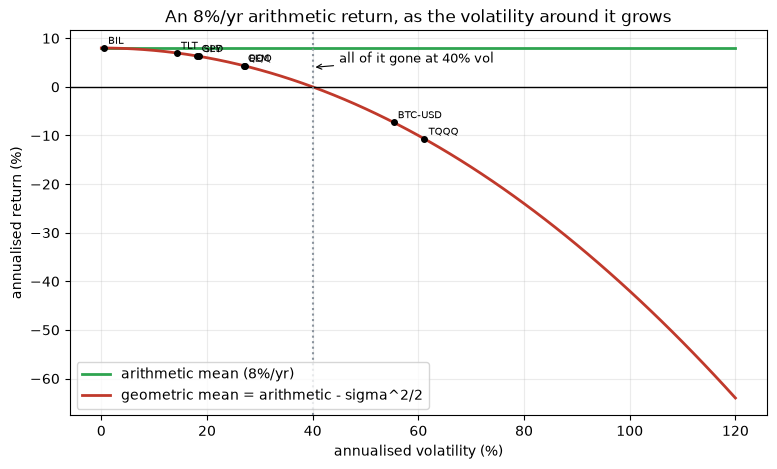

In [5]:
curve = st.drag_curve(vols=np.linspace(0, 1.2, 61), mu_ann=0.08)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve.index * 100, curve["arithmetic"] * 100, lw=2, color="#2ea44f",
        label="arithmetic mean (8%/yr)")
ax.plot(curve.index * 100, curve["geometric_approx"] * 100, lw=2, color="#c0392b",
        label="geometric mean = arithmetic - sigma^2/2")
ax.axhline(0, color="k", lw=1)
be = np.sqrt(2 * 0.08) * 100
ax.axvline(be, color="#8b949e", ls=":", lw=1.5)
ax.annotate(f"all of it gone at {be:.0f}% vol", (be, 4), xytext=(be + 5, 5), fontsize=9,
            arrowprops=dict(arrowstyle="->", lw=0.8))
for tk, row in dt.iterrows():
    ax.plot(row["vol_ann"] * 100, 8 - (row["vol_ann"] ** 2 / 2) * 100, "o", color="k", ms=4)
    ax.annotate(tk, (row["vol_ann"] * 100, 8 - (row["vol_ann"] ** 2 / 2) * 100),
                fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("annualised volatility (%)"); ax.set_ylabel("annualised return (%)")
ax.set_title("An 8%/yr arithmetic return, as the volatility around it grows")
ax.legend()
plt.show()

### 4.4 The bug worth grepping for

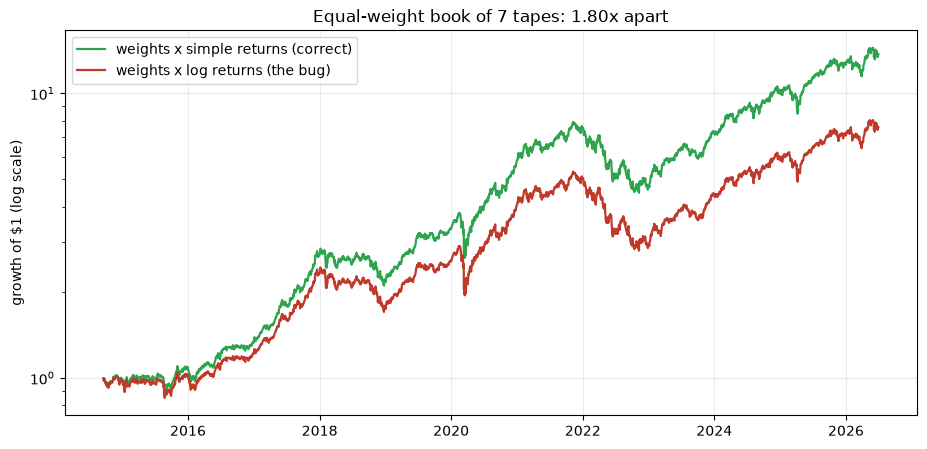

correct CAGR +24.96% | wrong CAGR +18.85% | gap +6.11%/yr over 11.8 years


In [6]:
universe = tuple(tk for tk in data.TICKERS if tk != "BIL")
err = st.portfolio_error(px, universe)
sub = px[list(universe)].dropna()
R = sub.pct_change().dropna()
L = np.log(sub / sub.shift(1)).dropna()
w = np.full(len(universe), 1 / len(universe))
right = (1 + st.portfolio_simple(R, w)).cumprod()
wrong = (1 + np.expm1(st.portfolio_from_logs(L, w))).cumprod()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(right.index, right, lw=1.6, color="#2ea44f", label="weights x simple returns (correct)")
ax.plot(wrong.index, wrong, lw=1.6, color="#c0392b", label="weights x log returns (the bug)")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title(f"Equal-weight book of {len(universe)} tapes: {err['terminal_ratio']:.2f}x apart")
ax.legend()
plt.show()
print(f"correct CAGR {err['cagr_correct']:+.2%} | wrong CAGR {err['cagr_wrong']:+.2%} | "
      f"gap {err['cagr_gap']:+.2%}/yr over {err['years']:.1f} years")

## 5 · The verdict

**Signal: Real.** It scales with the square of volatility, so it is invisible at one end of the tape and enormous at the other. On **BIL** (0% annualised vol) the mean simple and mean log returns differ by **0.00%/yr**; on **TQQQ** (61% vol) they differ by **18.9%/yr**, and the sigma-squared-over-two prediction accounts for 99% of it. The Sharpe ratio moves too: up to **0.31** between the two conventions.

**Usefulness: Useful.** Yes, and it is two lines. **Across time, use logs** (they add, and their mean exponentiates to the CAGR the path delivered). **Across assets, use simple returns** (a portfolio's return is a weighted average of them, exactly). The failure mode is weighting log returns: on an equal-weight book of 7 tapes it understated the CAGR by **6.11%/yr** — 1.80x of terminal wealth over 12 years — and it understated on **essentially every day**, because Jensen's inequality only points one way.

## 6 · What to do about it

Three lines, and they settle every case:

1. Compounding a single asset through time → **log returns**.
2. Combining assets into a portfolio → **simple returns**.
3. Publishing "the average return" → say **arithmetic** or **geometric**, and if you only have
   room for one, publish the geometric, because that is the one your investor experienced.

## 7 · Going further \U0001F6AA

- **Continuous rebalancing** turns the portfolio gap into Fernholz's excess growth rate — the
  same number, derived from stochastic portfolio theory rather than from Jensen.
- **Leveraged funds** (studies 942-944) are this effect industrialised: 3× daily exposure
  multiplies the variance by nine and the drag with it.
- **Currency conversion** stacks another log/simple decision on top; a EUR investor in a USD
  fund has two conventions to get right, not one.